# SIREN Testing

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import gc

import sys
from pathlib import Path

# Add parent directory to path
sys.path.append(str(Path.cwd().parent))

from models import KDV

In [12]:
INIT_PARAMS = dict(
    num_solitons             = 1,
    n_hidden_layers          = 6, 
    n_neurons_per_layer      = 32, 
    nl_outer                 = False,
    omega                    = 10,
    seed                     = 72, 
    verbose                  = True,
)

TRAIN_PARAMS = dict(
    adam_epochs              = 100000,
    verbose_step             = 100,
    n_collocation            = 50000, 
    n_initial                = 30000,  
    n_boundary               = 10000,
    n_momentum               = 0, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
    n_energy                 = 0,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
    adam_lr                  = 1e-3,   
    lbfgs_lr                 = 1.0,    
    lbfgs_history_size       = 100, 
    lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
    adaptive_sampling        = False,   
    logging                  = True, #new parameter, stops loss logging bottleneck for quick training (no loss history)
    verbose                  = True,
)

TRAIN_WEIGHTS = dict( #seperated out from the train params
    w_ic                     = 100.0,    
    w_bc                     = 2.0,    
    w_pde                    = 15.0,
    w_momentum               = 1.0,
    w_energy                 = 0.1,
)

model = KDV(INIT_PARAMS)
training_stats, _ = model.fit(TRAIN_PARAMS, TRAIN_WEIGHTS)

Using device: cuda
Weighted losses [start]: IC=1.023e+00 | BC=5.854e-03 | PDE=6.638e+04
Starting Adam optimization...
[gpu mem] train start               alloc  2980.8 MB  reserved  3238.0 MB  peak  2980.8 MB
Adam - Epoch 0/100000, Total Loss: 6.637665e+04
Adam - Epoch 100/100000, Total Loss: 4.433294e+00
Adam - Epoch 200/100000, Total Loss: 2.238669e+00
Adam - Epoch 300/100000, Total Loss: 1.560582e+00
Adam - Epoch 400/100000, Total Loss: 1.254330e+00
Adam - Epoch 500/100000, Total Loss: 1.090222e+00
Adam - Epoch 600/100000, Total Loss: 9.920884e-01
Adam - Epoch 700/100000, Total Loss: 9.285637e-01
Adam - Epoch 800/100000, Total Loss: 8.849551e-01
Adam - Epoch 900/100000, Total Loss: 8.536592e-01
Adam - Epoch 1000/100000, Total Loss: 8.304123e-01
Adam - Epoch 1100/100000, Total Loss: 8.126602e-01
Adam - Epoch 1200/100000, Total Loss: 7.987953e-01
Adam - Epoch 1300/100000, Total Loss: 7.877582e-01
Adam - Epoch 1400/100000, Total Loss: 7.788318e-01
Adam - Epoch 1500/100000, Total Loss: 

KeyboardInterrupt: 

In [19]:
TRAIN_PARAMS_2 = dict(
    adam_epochs              = 100000,
    verbose_step             = 100,
    n_collocation            = 50000, 
    n_initial                = 30000,  
    n_boundary               = 10000,
    n_momentum               = 10, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
    n_energy                 = 10,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
    adam_lr                  = 1e-4,   
    lbfgs_lr                 = 1.0,    
    lbfgs_history_size       = 100, 
    lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
    adaptive_sampling        = False,   
    logging                  = True, #new parameter, stops loss logging bottleneck for quick training (no loss history)
    verbose                  = True,
)

TRAIN_WEIGHTS = dict( #seperated out from the train params
    w_ic                     = 1.0,    
    w_bc                     = 2.0,    
    w_pde                    = 150.0,
    w_momentum               = 1.0,
    w_energy                 = 0.1,
)
model.fit(TRAIN_PARAMS_2, TRAIN_WEIGHTS)

Weighted losses [start]: IC=5.668e-06 | BC=8.911e-08 | PDE=4.753e-01
Starting Adam optimization...
[gpu mem] train start               alloc  4591.0 MB  reserved  4928.0 MB  peak  4591.0 MB
Adam - Epoch 0/100000, Total Loss: 3.693505e+00
Adam - Epoch 100/100000, Total Loss: 2.240713e-02
Adam - Epoch 200/100000, Total Loss: 2.188090e-02
Adam - Epoch 300/100000, Total Loss: 2.161983e-02
Adam - Epoch 400/100000, Total Loss: 2.145211e-02
Adam - Epoch 500/100000, Total Loss: 2.135117e-02
Adam - Epoch 600/100000, Total Loss: 2.130214e-02
Adam - Epoch 700/100000, Total Loss: 2.127275e-02
Adam - Epoch 800/100000, Total Loss: 2.125145e-02
Adam - Epoch 900/100000, Total Loss: 2.123479e-02
Adam - Epoch 1000/100000, Total Loss: 2.122210e-02
Adam - Epoch 1100/100000, Total Loss: 2.121297e-02


KeyboardInterrupt: 

In [3]:
torch.cuda.empty_cache()

In [4]:
#del model
#del training_stats
torch.cuda.memory_allocated()

19133440

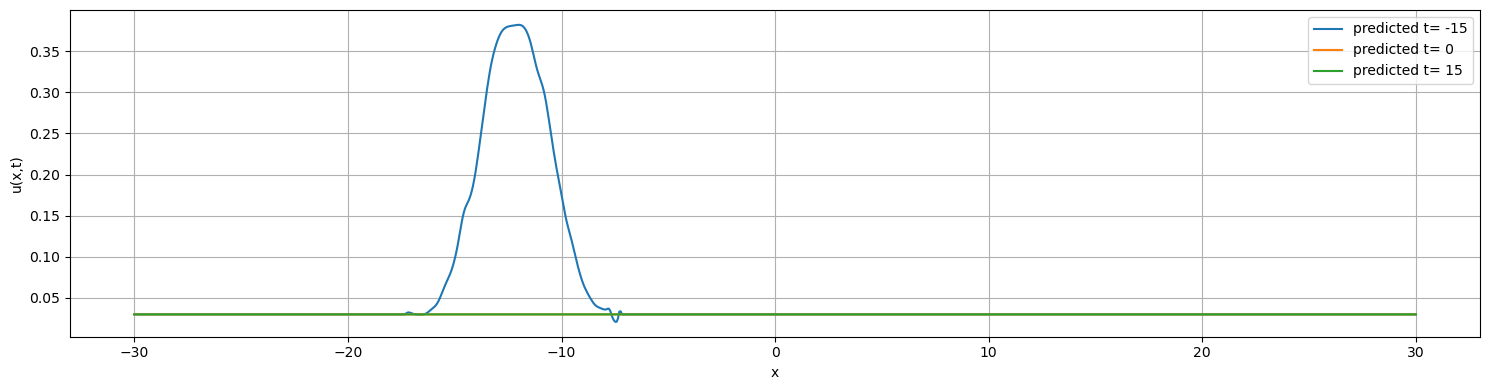

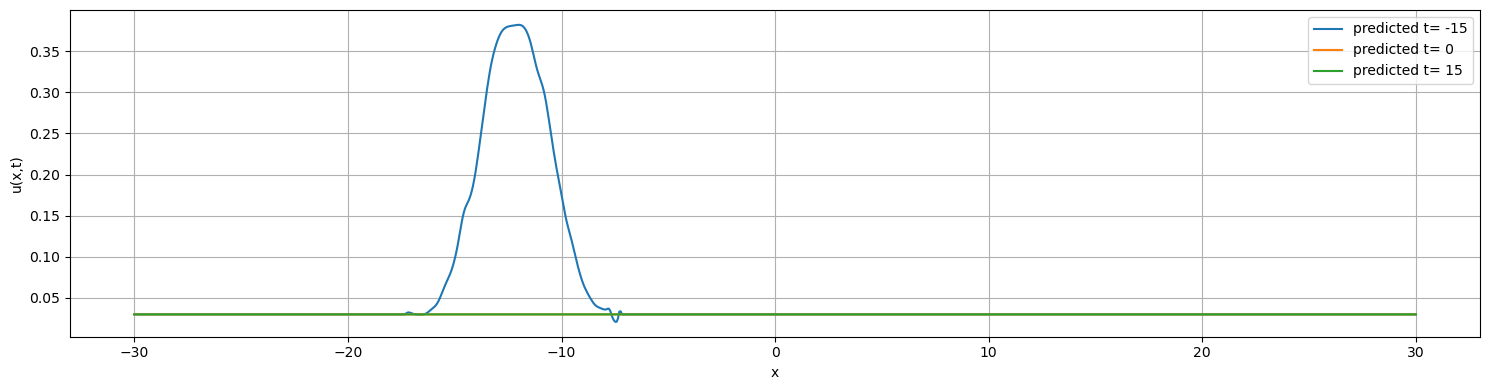

In [20]:
model.plot_profiles(t_values=[-15, 0, 15])